# Laboratory 2.3: Linear Regression

In this practice you will build your own Linear Regression model. As you _should_ remember, we have seen in class how to obtain the optimal values for the parameters in a linear regression model. If you need to refresh your memory, check the slides from theory for the formula for the model optimization.

For the final part of this practice you will also need the following dataset:
- **winequality.csv**: Dataset with several input variables and a continuous output variable to determine wine quality. You can get more information from the [original repository](https://archive.ics.uci.edu/dataset/186/wine+quality).


In addition, we will be using the following libraries:
- Data management:
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)
- Modelling:
    - [scikit-learn](https://scikit-learn.org)
- Plotting:
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)

In [17]:
# Import here whatever you may need
import numpy as np
import sys
import os

# Get the absolute path of the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add it to sys.path
sys.path.insert(0, project_root)

from src.lab_2_3_LinearRegression import LinearRegressor, evaluate_regression, sklearn_comparison, anscombe_quartet

In [18]:
# Define data to use in this practice
x = np.array([0, 3, 2, 1, 4, 6, 7, 8, 9, 10])
y = np.array([2, 3, 2, 4, 5, 7, 9, 9, 10, 13])

In [19]:
### Train your linear regression model
linreg = LinearRegressor()
linreg.fit_simple(x, y)

1.0363636363636364


In [20]:
# Obtain regression performance metrics
y_pred = linreg.predict(x)
evaluation_metrics = evaluate_regression(y, y_pred)
print(evaluation_metrics)

{'R2': np.float64(0.9201359388275275), 'RMSE': np.float64(1.0126472956832235), 'MAE': np.float64(0.8945454545454549)}


### Scikit-Learn comparison

In [21]:
### Compare your model with sklearn linear regression model
sklearn_comparison(x, y, linreg)


Custom Model Coefficient: 1.0363636363636364
Custom Model Intercept: 1.2181818181818187
Scikit-Learn Coefficient: 1.036363636363637
Scikit-Learn Intercept: 1.2181818181818151


{'custom_coefficient': np.float64(1.0363636363636364),
 'custom_intercept': np.float64(1.2181818181818187),
 'sklearn_coefficient': np.float64(1.036363636363637),
 'sklearn_intercept': np.float64(1.2181818181818151)}

### Anscombe's quartet

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

anscombe, datasets, models, result = anscombe_quartet()

0.5000909090909093
Dataset I: Coefficient: 0.5000909090909093, Intercept: 3.0000909090909094
R2: 0.6665424595087748, RMSE: 1.1185497916336298, MAE: 0.837404958677686
0.5000000000000001
Dataset II: Coefficient: 0.5000000000000001, Intercept: 3.000909090909089
R2: 0.6662420337274844, RMSE: 1.1191023557497446, MAE: 0.9679338842975209
0.49972727272727285
Dataset III: Coefficient: 0.49972727272727285, Intercept: 3.002454545454544
R2: 0.6663240410665592, RMSE: 1.118285693623049, MAE: 0.7159669421487606
0.49990909090909086
Dataset IV: Coefficient: 0.49990909090909086, Intercept: 3.0017272727272735
R2: 0.6667072568984653, RMSE: 1.1177286221293936, MAE: 0.9027272727272727


**Questions:** What do you think about the fit? Do you notice something? Comment it here below:



`You answer here`
Podemos observar que aunque los datasets tienen puntos distribuidos de manera muy distinta, los coeficientes y el intercepto obtenido con nuestro modelo es prácticamente igual. Eso se debe a que la regresión lineal solo ve varianzas y covarianzas y estos datasets están construidos para tener varianzas y covarianzas parecidas aunque tengan datos distribuidos de manera muy distinta. Por ello, nuestro modelo de regresión obtiene estimaciones prácticamente iguales. Para distribuciones de datos no lineales, esto es un claro ejemplo de una desventaja de la regresión lineal..



Once all models are trained (one for each dataset), we will plot the results of the fit alongside each point set

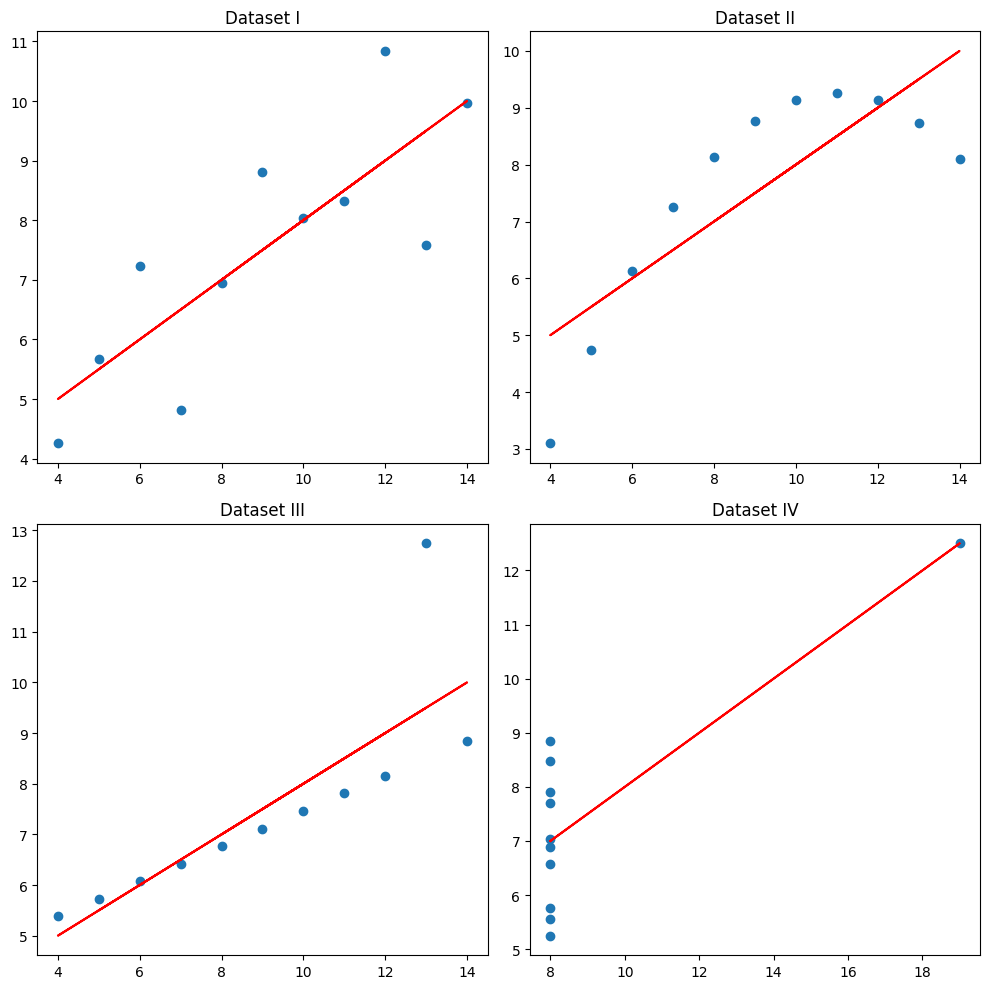

In [ ]:
# Visualizing the datasets with their regression lines
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()

for i, dataset in enumerate(datasets):

    # TODO: Select the dataset for each case
    data = anscombe[anscombe["dataset"] == dataset]
    axs[i].scatter(data['x'], data['y'])

    # TODO: Plot the data and the fit (fill the "None" value)
    y = models[dataset].predict(data["x"]) #sacamos el modelo obtenido para cada dataset.
    axs[i].plot(data['x'], y, color='red')  # Regression line
    axs[i].set_title(f"Dataset {dataset}")

plt.tight_layout()
plt.show()


### Multiple variable linear regression

In this section, we are going to use the dataset of the quality of red wines based on chemical measurements. The original dataset can be found in the [UCI Repository](https://archive.ics.uci.edu/dataset/186/wine+quality).

In [24]:
import pandas as pd

wine_data = pd.read_csv("data/winequality.csv", sep=';')

In [25]:
# Divide dataset between inputs and output
inputs = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']
output = 'quality'

X = wine_data[inputs]
y = wine_data[output]

In [26]:
# Train multiple regression model
linreg_multiple = LinearRegressor()
linreg_multiple.fit_multiple(X, y)

21.96520843560771
[ 2.49905527e-02 -1.08359026e+00 -1.82563948e-01  1.63312698e-02
 -1.87422516e+00  4.36133331e-03 -3.26457970e-03 -1.78811638e+01
 -4.13653144e-01  9.16334413e-01  2.76197699e-01]


In [27]:
# Obtain regression performance metrics
y_pred = linreg_multiple.predict(X)
evaluation_metrics = evaluate_regression(y, y_pred)
print(evaluation_metrics)

{'R2': np.float64(0.36055170303868833), 'RMSE': np.float64(0.6455750670692045), 'MAE': np.float64(0.5004899635932898)}
